In [2]:
import pandas as pd
def cargar_datos(path):
    # Carga el archivo CSV en un DataFrame de pandas
    df = pd.read_csv(path)
    return df
def analisis_rapido(df):
    # Realiza un análisis rápido del DataFrame
    resumen = {
        "Primeras_filas": df.head(),
        "tamaño": df.shape,
        "tipos_de_datos": df.dtypes,
        "estadisticas_descriptivas": df.describe(),
        "nombres_de_columnas": df.columns.tolist()
    }
    return resumen
def cambio_nombre_columnas(df, nuevo_nombre):
    # Copia del DataFrame original para no modificarlo directamente
    if len(nuevo_nombre) != len(df.columns):
        raise ValueError("La lista de nuevos nombres debe tener la misma longitud que el número de columnas del DataFrame.")
    df = df.copy()
    df.columns = nuevo_nombre
    return df
def cambio_tipo_datos_datetime(df, columna):
    # Copia del DataFrame original para no modificarlo directamente)
    df[columna] = pd.to_datetime(df[columna], errors='coerce')  # Convierte la columna a tipo datetime, manejando errores")
    return df
df = cargar_datos( r"D:\TODO\Python\files\Dataset\global_climate_energy_2020_2024.csv")
df = cambio_nombre_columnas(
    df,
    [
    "Fecha",
    "Pais",
    "Temperatura_promedio_C°",
    "Humedad_%",
    "Emisiones_CO2",
    "Consumo_energia_MWh",
    "Porcentaje_de_Energia_renovable_%",
    "Poblacion_urbana",
    "Indic_de_actividad_industrial",
    "Precio_energia_electrica_€/MWh"
    ]
)
df = cambio_tipo_datos_datetime(df, "Fecha")
resumen = analisis_rapido(df)
print("Resumen del análisis rápido:")
print(resumen)


Resumen del análisis rápido:
{'Primeras_filas':        Fecha     Pais  Temperatura_promedio_C°  Humedad_%  Emisiones_CO2  \
0 2020-01-01  Germany                    28.29      31.08         212.63   
1 2020-01-02  Germany                    28.38      37.94         606.05   
2 2020-01-03  Germany                    28.74      57.67         268.72   
3 2020-01-04  Germany                    26.66      51.34         167.32   
4 2020-01-05  Germany                    26.81      65.38         393.89   

   Consumo_energia_MWh  Porcentaje_de_Energia_renovable_%  Poblacion_urbana  \
0             11348.75                              14.42             76.39   
1              4166.64                               5.63             86.26   
2              4503.80                              14.20             75.92   
3              3259.13                              13.84             63.15   
4              7023.72                               6.93             76.02   

   Indic_de_activida

             Pais   Año  Consumo_energia_MWh
0       Australia  2020           2576351.45
1       Australia  2021           2593784.77
2       Australia  2022           2666483.95
3       Australia  2023           2768058.43
4       Australia  2024           2622615.05
..            ...   ...                  ...
95  United States  2020           2651108.03
96  United States  2021           2672183.97
97  United States  2022           2745608.87
98  United States  2023           2698066.65
99  United States  2024           2725485.11

[100 rows x 3 columns]


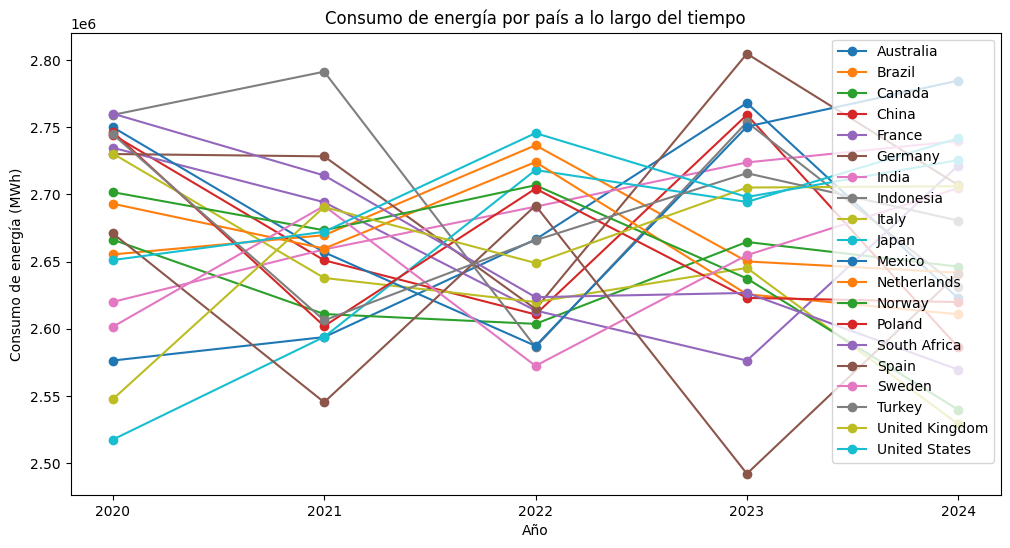

In [3]:
import matplotlib.pyplot as plt
# Agrupación por país y año, calculando la media del consumo de energía
# import matplotlib.pyplot as plt
Agrupacion = df.groupby(["Pais", df["Fecha"].dt.year.rename("Año")])["Consumo_energia_MWh"].sum().reset_index()
print(Agrupacion)
plt.figure(figsize=(12, 6))
for pais in Agrupacion["Pais"].unique():
    datos = Agrupacion[Agrupacion["Pais"] == pais]
    plt.plot(datos["Año"],
             datos["Consumo_energia_MWh"],
             label=pais,
             marker='o'
           
             )
plt.xticks(Agrupacion["Año"].unique())  # Asegura que todos los años estén en el eje x
plt.legend(loc="best")
plt.xlabel("Año")
plt.ylabel("Consumo de energía (MWh)")
plt.title("Consumo de energía por país a lo largo del tiempo")  
plt.show()



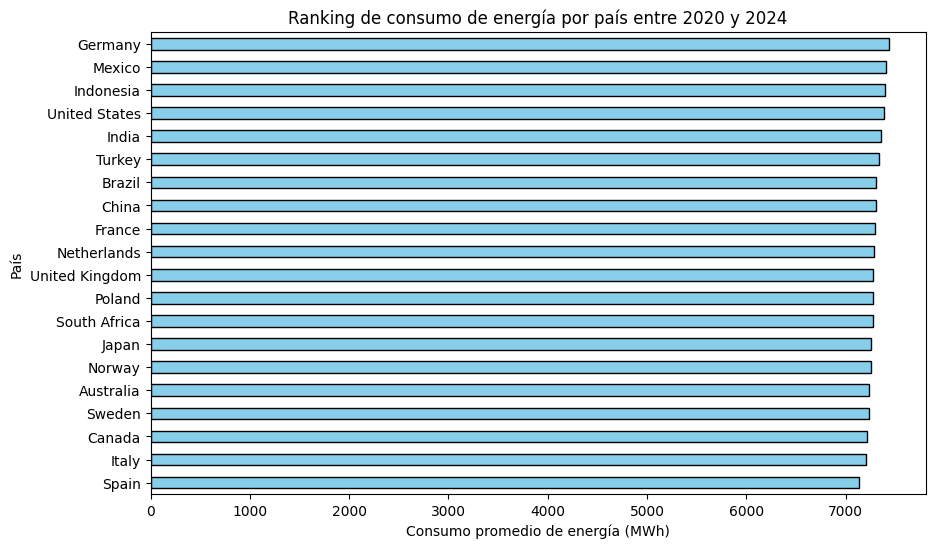

In [4]:
ranking = df.groupby("Pais")["Consumo_energia_MWh"].mean().sort_values(ascending=True)
ranking.plot(kind="barh", figsize=(10, 6), color="skyblue", edgecolor="black") 
plt.xlabel("Consumo promedio de energía (MWh)")    
plt.ylabel("País")
plt.title("Ranking de consumo de energía por país entre 2020 y 2024")
plt.show()

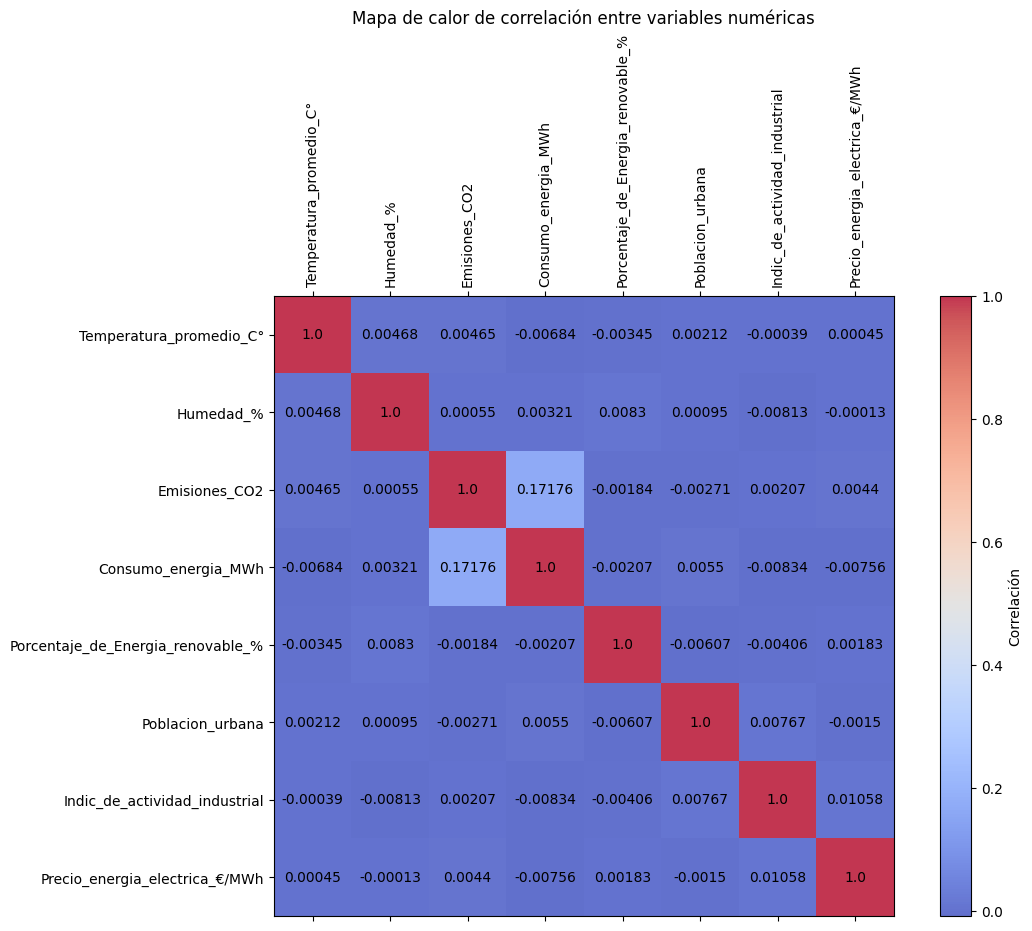

In [5]:
# Mostrar la correlacion entre las variables numéricas
Variables_numericas = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
correlacion = df[Variables_numericas].corr()
plt.figure(figsize=(12, 8))
# matshow ayuda a visualizar la correlación entre las variables numéricas en un mapa de calor
plt.matshow(correlacion, cmap='coolwarm',alpha=0.8, fignum=1)
plt.colorbar(label='Correlación')
plt.xticks(range(len(Variables_numericas)), Variables_numericas, rotation=90)
plt.yticks(range(len(Variables_numericas)), Variables_numericas)
for i in range(len(Variables_numericas)):
    for j in range(len(Variables_numericas)):
        plt.text(i, j,round(correlacion.iloc[i, j], 5), ha='center', va='center', color='black')
plt.title("Mapa de calor de correlación entre variables numéricas",)
plt.show()


Correlación entre Porcentaje de Energía renovable y Emisiones de CO2 para Germany: 0.0037
Correlación entre Consumo de energía y Emisiones de CO2 para Germany: 0.1728


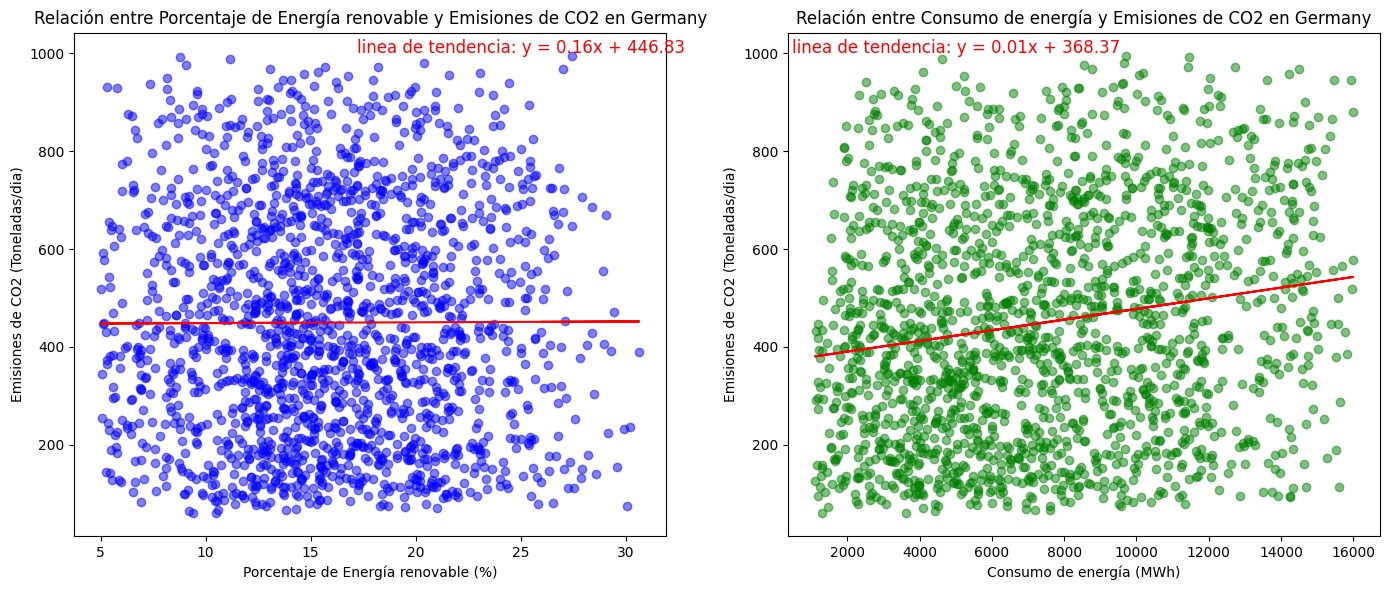

In [6]:
import numpy as np
# Scatter plot entre la relación las emsiones de CO con el consumo de energía y el porcentaje de energía renovable
def relacion(df,pais):
    datos_pais = df[df["Pais"] == pais]
    if datos_pais.empty:
        print(f"No se encontraron datos para el país: {pais}")
        return
    # calculamos la correlación entre las dos variables
    correlacion_renovable = datos_pais[["Porcentaje_de_Energia_renovable_%","Emisiones_CO2"]].corr().iloc[0, 1]
    print(f"Correlación entre Porcentaje de Energía renovable y Emisiones de CO2 para {pais}: {correlacion_renovable:.4f}")
    correlacio_consumo = datos_pais[["Consumo_energia_MWh","Emisiones_CO2"]].corr().iloc[0, 1]
    print(f"Correlación entre Consumo de energía y Emisiones de CO2 para {pais}: {correlacio_consumo:.4f}")
    # Creamos el scatter plot
    fig,ax = plt.subplots(1, 2, figsize=(14, 6))
    x = datos_pais["Porcentaje_de_Energia_renovable_%"]
    y = datos_pais["Emisiones_CO2"]
    ax[0].scatter(x, y, color='blue', alpha=0.5)
    ax[0].set_title(f"Relación entre Porcentaje de Energía renovable y Emisiones de CO2 en {pais}")
    m,b = np.polyfit(x, y, 1)
    ax[0].plot(x, m*x + b, color='red')  # Agregamos la línea de tendencia
    ax[0].set_xlabel("Porcentaje de Energía renovable (%)")
    ax[0].set_ylabel("Emisiones de CO2 (Toneladas/dia)")
    ax[0].text(25, 1000, f"linea de tendencia: y = {m:.2f}x + {b:.2f}", fontsize=12, color='red', ha='center')
    ax[1].scatter(datos_pais["Consumo_energia_MWh"], datos_pais["Emisiones_CO2"], color='green', alpha=0.5)
    ax[1].set_title(f"Relación entre Consumo de energía y Emisiones de CO2 en {pais}")
    m2,b2 = np.polyfit(datos_pais["Consumo_energia_MWh"], datos_pais["Emisiones_CO2"], 1)
    ax[1].plot(datos_pais["Consumo_energia_MWh"], m2*datos_pais["Consumo_energia_MWh"] + b2, color='red')  # Agregamos la línea de tendencia
    ax[1].set_xlabel("Consumo de energía (MWh)")    
    ax[1].set_ylabel("Emisiones de CO2 (Toneladas/dia)")
    ax[1].text(5000, 1000, f"linea de tendencia: y = {m2:.2f}x + {b2:.2f}", fontsize=12, color='red', ha='center')
    plt.tight_layout()
    plt.show()
    
# Eliges el país para el que deseas ver la relación entre las variables
relacion(df,"Germany")
# Cabe ver que las varibles parecen poca relacion entre si 

   


CO2 = 445.5328 + (0.2532)*Temperatura_promedio_C° + (0.7292)*Humedad_% + (39.7234)*Consumo_energia_MWh + (-0.1795)*Porcentaje_de_Energia_renovable_% + (-0.2497)*Poblacion_urbana + (1.0275)*Indic_de_actividad_industrial + (0.8907)*Precio_energia_electrica_€/MWh
R² Score: 0.0329


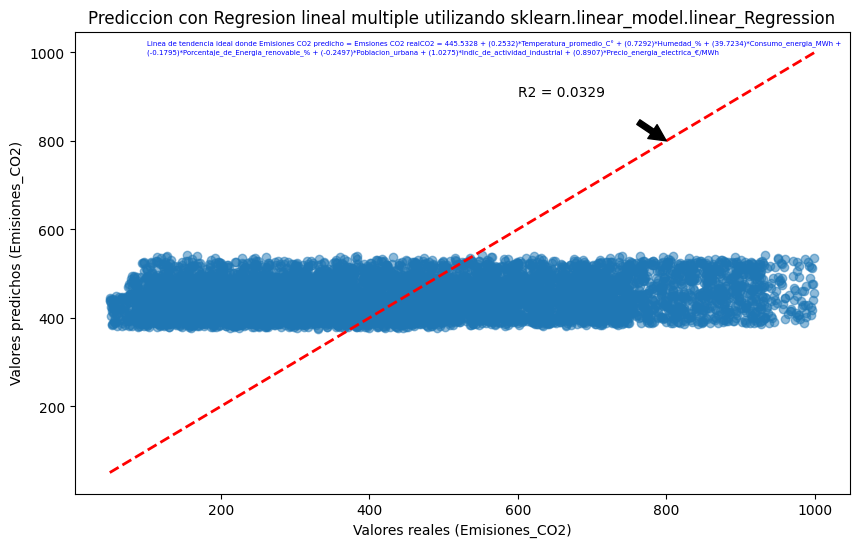

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
Variables = ['Temperatura_promedio_C°','Humedad_%','Consumo_energia_MWh','Porcentaje_de_Energia_renovable_%','Poblacion_urbana','Indic_de_actividad_industrial','Precio_energia_electrica_€/MWh']
if len(Variables) == 0:
    print("Lista de variables causales vacio"
          )
scaler = StandardScaler()
x= df[Variables]
y = df["Emisiones_CO2"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=45)
modelo = LinearRegression(n_jobs=-1)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
modelo.fit(x_train,y_train)
prediccion = modelo.predict(x_test)
coeficientes = modelo.coef_
tabla = pd.DataFrame(
    {"Variables": x.columns,
    "coeficientes": coeficientes

    }
    
)
tabla.sort_values(by="coeficientes",ascending=False)
formula = f"CO2 = {modelo.intercept_:.4f}"

for variable, coef in zip(x.columns, coeficientes):
     formula += f" + ({coef:.4f})*{variable}"
print(formula)
r2 = r2_score(y_test, prediccion)
print(f"R² Score: {r2:.4f}")
texto = (
         f"{formula}")
plt.figure(figsize=(10, 6))
plt.scatter(y_test, prediccion, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Valores reales (Emisiones_CO2)")
plt.ylabel("Valores predichos (Emisiones_CO2)")
plt.text(100,1000,texto,color = "blue",fontsize = 5, wrap =True )
plt.annotate(f"R2 = {r2:.4f}",xy=(800,800),xytext=(600,900),arrowprops=dict(facecolor = "black",shrink = 0.5))
plt.title("Prediccion con Regresion lineal multiple utilizando sklearn.linear_model.linear_Regression")
plt.show()


